<a href="https://colab.research.google.com/github/uppupushpa/practice/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd

#Sample dataset
data={
    "Name":["Pushpa","Abhi","Bob","Charlie"],
    "Age":[25,30,35,40],
    "Gender":["Female","Female","Male","Male"],
    "Salary":[30000,40000,50000,60000],
    "Joining_Date":["2025-01-01","2024-06-25","2023-08-30","2022-10-12"]
}
df=pd.DataFrame(data)
df

,Name,Age,Gender,Salary,Joining_Date
0,Pushpa,25,Female,30000,2025-01-01
1,Abhi,30,Female,40000,2024-06-25
2,Bob,35,Male,50000,2023-08-30
3,Charlie,40,Male,60000,2022-10-12


In [56]:
#Checking data types
df.dtypes

,0
Name,object
Age,int64
Gender,object
Salary,int64
Joining_Date,object


In [57]:
#Handling Numerical data
import pandas as pd
import numpy as np

#Sample numerical data
data={
    "Age":[18,20,22,45,60],
    "Salary":[20000,30000,32000,50000,80000]
}
df=pd.DataFrame(data)
df

,Age,Salary
0,18,20000
1,20,30000
2,22,32000
3,45,50000
4,60,80000


In [58]:
#Feature Scaling-Standardization
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df_scaled=df.copy()
df_scaled[["Age","Salary"]]=scaler.fit_transform(df[["Age","Salary"]])

df_scaled

,Age,Salary
0,-0.900288,-1.059436
1,-0.780250,-0.586474
2,-0.660211,-0.491881
3,0.720231,0.359452
4,1.620519,1.778339


In [59]:
#Feature Scaling Normalization(Min-Max)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

df_normalized=df.copy()
df_normalized[["Age","Salary"]]=scaler.fit_transform(df[["Age","Salary"]])

df_normalized

,Age,Salary
0,0.000000,0.000000
1,0.047619,0.166667
2,0.095238,0.200000
3,0.642857,0.500000
4,1.000000,1.000000


In [60]:
#Log Transformation
df_log=df.copy()
df_log["Salary_Log"]=np.log(df_log["Salary"])

df_log

,Age,Salary,Salary_Log
0,18,20000,9.903488
1,20,30000,10.308953
2,22,32000,10.373491
3,45,50000,10.819778
4,60,80000,11.289782


In [61]:
#Binning(Discretization)
#Create bins for Age
bins=[0,20,40,100]
labels=["Young","Adult","Senior"]

df["Age_Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

df

,Age,Salary,Age_Group
0,18,20000,Young
1,20,30000,Young
2,22,32000,Adult
3,45,50000,Senior
4,60,80000,Senior


In [62]:
#Handling Categorical data
import pandas as pd
data={
    "Name":["A","B","C","D","E","F"],
    "Gender":["Male","Female","Female","Male","Male","Other"],
    "City":["Mumbai","Delhi","Mumbai","Pune","Delhi","Delhi"],
    "Performance":["Low","Medium","High","Low","Medium","High"]
}
df=pd.DataFrame(data)
df

,Name,Gender,City,Performance
0,A,Male,Mumbai,Low
1,B,Female,Delhi,Medium
2,C,Female,Mumbai,High
3,D,Male,Pune,Low
4,E,Male,Delhi,Medium
5,F,Other,Delhi,High


In [63]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df["Gender_Label"]=le.fit_transform(df["Gender"])
df["City_Label"]=le.fit_transform(df["City"])
df

,Name,Gender,City,Performance,Gender_Label,City_Label
0,A,Male,Mumbai,Low,1,1
1,B,Female,Delhi,Medium,0,0
2,C,Female,Mumbai,High,0,1
3,D,Male,Pune,Low,1,2
4,E,Male,Delhi,Medium,1,0
5,F,Other,Delhi,High,2,0


In [64]:
#Ordinal Encoding
order={"Low": 3,"Medium": 2,"High": 1}

df["Performance_Ordinal"]=df["Performance"].map(order)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal
0,A,Male,Mumbai,Low,1,1,3
1,B,Female,Delhi,Medium,0,0,2
2,C,Female,Mumbai,High,0,1,1
3,D,Male,Pune,Low,1,2,3
4,E,Male,Delhi,Medium,1,0,2
5,F,Other,Delhi,High,2,0,1


In [65]:
#Frequency Encoding
freq=df["City"].value_counts()

df["City_Freq"]=df["City"].map(freq)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq
0,A,Male,Mumbai,Low,1,1,3,2
1,B,Female,Delhi,Medium,0,0,2,3
2,C,Female,Mumbai,High,0,1,1,2
3,D,Male,Pune,Low,1,2,3,1
4,E,Male,Delhi,Medium,1,0,2,3
5,F,Other,Delhi,High,2,0,1,3


In [66]:
#Target Encoding
#Create a dummy target variable
df["Target"]=[0,1,1,0,1,2]

#Calculate mean target per category
target_mean=df.groupby("City")["Target"].mean
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq,Target
0,A,Male,Mumbai,Low,1,1,3,2,0
1,B,Female,Delhi,Medium,0,0,2,3,1
2,C,Female,Mumbai,High,0,1,1,2,1
3,D,Male,Pune,Low,1,2,3,1,0
4,E,Male,Delhi,Medium,1,0,2,3,1
5,F,Other,Delhi,High,2,0,1,3,2


In [67]:
#Handling date and time
import pandas as pd
data={
    "Name": ["A","B","C"],
    "Joining_Date": ["2022-01-15","2021-06-20","2020-12-05"]
}
df=pd.DataFrame(data)

df["Joining_Date"]=pd.to_datetime(df["Joining_Date"])
df

,Name,Joining_Date
0,A,2022-01-15
1,B,2021-06-20
2,C,2020-12-05


In [68]:
#Extract Data Features
df["Year"]=df["Joining_Date"].dt.year
df["Moonth"]=df["Joining_Date"].dt.month
df["Day"]=df["Joining_Date"].dt.day
df["Weekday"]=df["Joining_Date"].dt.day_name()

df

,Name,Joining_Date,Year,Moonth,Day,Weekday
0,A,2022-01-15,2022,1,15,Saturday
1,B,2021-06-20,2021,6,20,Sunday
2,C,2020-12-05,2020,12,5,Saturday


In [69]:
#Extract time features
#Create sample datetime with time
df["Full_DateTime"]=pd.to_datetime([
    "2022-01-15 10:30:00",
    "2021-06-20 14:45:00",
    "2020-12-05 08:15:00"
])

df["Hour"]=df["Full_DateTime"].dt.hour
df["Minute"]=df["Full_DateTime"].dt.minute
df

,Name,Joining_Date,Year,Moonth,Day,Weekday,Full_DateTime,Hour,Minute
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15


In [70]:
#Cyclical Encoding
import numpy as np
df["Month"]=df["Full_DateTime"].dt.month
#Apply on month
df["Month_sin"]=np.sin(2 * np.pi * df["Month"]/12)
df["Month_cos"]=np.cos(2 * np.pi * df["Month"]/12)
df

,Name,Joining_Date,Year,Moonth,Day,Weekday,Full_DateTime,Hour,Minute,Month,Month_sin,Month_cos
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30,1,5.000000e-01,0.866025
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45,6,1.224647e-16,-1.000000
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15,12,-2.449294e-16,1.000000


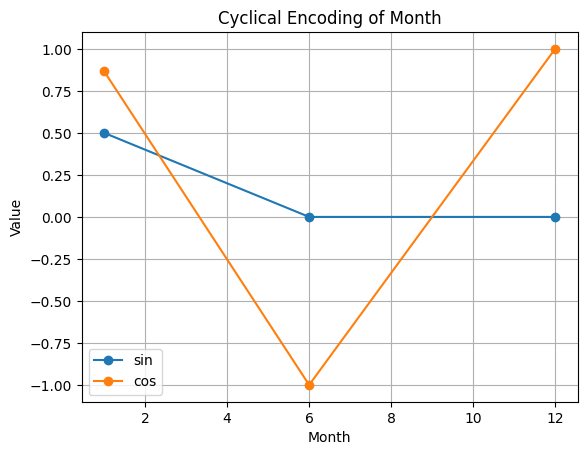

In [71]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["Month"],df["Month_sin"], marker='o', label="sin")
plt.plot(df["Month"],df["Month_cos"],marker='o',label="cos")

plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Month")
plt.legend()
plt.grid()

plt.show()

In [72]:
#Feature Creation
import pandas as pd
data={
    "Name":["A","B","C"],
    "Price":[100,200,150],
    "Quantity":[2,3,5],
    "First_Name":["John","Jane","Sam"],
    "Last_Name":["Doe","Smith","Brown"],
    "Email":["john@gmail.com","jane@yahoo.com","sam@outlook.com"]
}
df=pd.DataFrame(data)
df

,Name,Price,Quantity,First_Name,Last_Name,Email
0,A,100,2,John,Doe,john@gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com


In [74]:
#Mathematical Feature Creation
#Create total price
df["Total_Price"]=df["Price"] * df["Quantity"]
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price
0,A,100,2,John,Doe,john@gmail.com,200
1,B,200,3,Jane,Smith,jane@yahoo.com,600
2,C,150,5,Sam,Brown,sam@outlook.com,750


In [75]:
#Combining Features
df["Full_Name"]=df["First_Name"] + " " + df["Last_Name"]
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name
0,A,100,2,John,Doe,john@gmail.com,200,John Doe
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown


In [76]:
#Extracting Information
df["Email_Domain"]=df["Email"].apply(lambda x: x.split("@")[1])
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com


In [77]:
#Domain Based data
df["Weight"]=[60,70,80]
df["Height"]=[1.6,1.7,1.8]

df["BMI"]=df["Weight"] / (df["Height"] ** 2)
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain,Weight,Height,BMI
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com,60,1.6,23.437500
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com,70,1.7,24.221453
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com,80,1.8,24.691358


In [78]:
#Handling missing values
import pandas as pd
import numpy as np

data={
    "Age": [25,np.nan,30,35,np.nan],
    "Salary":[50000,60000,np.nan,80000,90000],
    "City": ["Mumbai","Delhi",None,"Pune","Delhi"]
}
df=pd.DataFrame(data)
df

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


In [79]:
df.isnull().sum()

,0
Age,2
Salary,1
City,1


In [80]:
#Mean Imputation
df2=df.copy()

df2["Age"]=df2["Age"].fillna(df2["Salary"].mean())
df2

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,70000.0,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,70000.0,90000.0,Delhi


In [82]:
print(df.columns)

Index(['Age', 'Salary', 'City'], dtype='object')


In [85]:
#Median Imputation
df2=df.copy()
df2["City"]=df2["City"].fillna(df2["Salary"].mode())
#df2["City"].fillna(df2["City"].mode()[0], inplace=True)
df2

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,80000.0
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


In [86]:
#Mode Imputation
df2=df.copy()
df2["City"]=df2["City"].fillna(df2["Salary"].mode())
#df2["City"].fillna(df2["City"].mode()[0], inplace=True)
df2

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,80000.0
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


In [87]:
#Forward fill
df_bfill=df.bfill()
#df_ffill=df.fillna(method="ffill")
df_bfill

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,80000.0,Pune
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


In [88]:
#Backward fill
df_bfill=df.bfill()
#df_bfill=df.fillna(method="bfill")
df_bfill

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,80000.0,Pune
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


In [39]:
#Missing Indicator
df["Age_missing"]=df["Age"].isnull().astype(int)
df

,Age,Salary,City,Age_missing
0,25.0,50000.0,Mumbai,0
1,NaN,60000.0,Delhi,1
2,30.0,NaN,None,0
3,35.0,80000.0,Pune,0
4,NaN,90000.0,Delhi,1


In [40]:
#Feature selection
import pandas as pd
data={
    "Age": [25,30,35,40,45],
    "Salary": [30000,40000,50000,60000,70000],
    "Experience": [1,3,5,7,9],
    "Purchased": [0,0,1,1,1]
}
df=pd.DataFrame(data)
df

,Age,Salary,Experience,Purchased
0,25,30000,1,0
1,30,40000,3,0
2,35,50000,5,1
3,40,60000,7,1
4,45,70000,9,1


In [41]:
#Correlation matrix
df.corr()

,Age,Salary,Experience,Purchased
Age,1.000000,1.000000,1.000000,0.866025
Salary,1.000000,1.000000,1.000000,0.866025
Experience,1.000000,1.000000,1.000000,0.866025
Purchased,0.866025,0.866025,0.866025,1.000000


In [42]:
#Selection Important Features
corr_with_target=df.corr()["Purchased"]
corr_with_target

,Purchased
Age,0.866025
Salary,0.866025
Experience,0.866025
Purchased,1.000000


In [43]:
#Example: Drop a feature (if low importance)
df_selected=df.drop(columns=["Age"])
df_selected

,Salary,Experience,Purchased
0,30000,1,0
1,40000,3,0
2,50000,5,1
3,60000,7,1
4,70000,9,1


In [44]:
#Handling Outliers
import pandas as pd
data={
    "Salary": [30000,35000,40000,45000,50000,1000000]
}
df=pd.DataFrame(data)
df

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000
5,1000000


In [46]:
#Detect Outliers
Q1=df["Salary"].quantile(0.25)
Q3=df["Salary"].quantile(0.75)

IQR=Q3 - q1

lower_bound=Q1 - 1.5 * IQR
upper_bound=Q3 + 1.5 * IQR

lower_bound, upper_bound

outliers=df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
print(outliers)

    Salary
5  1000000


In [47]:
#Identify Outliers
outlier = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
outliers

,Salary
5,1000000


In [48]:
#Remove Outliers
df_no_outliers=df[(df["Salary"] >= lower_bound) & (df["Salary"] <= upper_bound)]
df_no_outliers

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000


In [49]:
#Cap Outliers
df_capped=df.copy()

df_capped["Salary"]=df_capped["Salary"].clip(lower_bound, upper_bound)
df_capped

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000
5,67500


In [50]:
#Z-Score Method
from scipy import stats
z_scores=stats.zscore(df["Salary"])
z_scores

array([-0.47508713, -0.46111398, -0.44714082, -0.43316767, -0.41919452,
        2.23570412])

In [51]:
#Identify Outliers using Z-Score
df_z=df[(abs(z_scores) > 2)]
df_z

,Salary
5,1000000
